# Étape 5 - Optimisation, évaluation finale et interprétation

Cette étape termine le projet côté modélisation :

1. **optimiser** les hyperparamètres de la forêt aléatoire retenue à l'étape 4, par
   validation croisée sur le seul jeu d'apprentissage ;
2. **évaluer une fois** le modèle final sur le jeu de test, resté fermé jusqu'ici ;
3. **interpréter** ce que le modèle a appris, et le confronter aux constats de l'EDA ;
4. **auditer** la fuite, la robustesse temporelle et les biais ;
5. **livrer** la pipeline complète et démontrer une prédiction sur une donnée brute.

L'objectif n'est pas d'obtenir le plus beau chiffre. C'est de savoir dans quelles
situations le modèle se trompe, et de le dire.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

PROJECT_PATH = Path.cwd().parent
DATA_PATH = PROJECT_PATH / 'csv' / 'dataset_phase3_final.csv'
FIGURE_PATH = PROJECT_PATH / 'figures_eda'
MODEL_PATH = PROJECT_PATH / 'modeles'
FIGURE_PATH.mkdir(exist_ok=True)
MODEL_PATH.mkdir(exist_ok=True)

TARGET = "6-Taux d'emploi salarié en France - 6 mois après le diplôme"
SORTANTS = '6-Nombre de sortants - 6 mois après le diplôme'
POURSUIVANTS = '6-Nombre de poursuivants - 6 mois après le diplôme'
CODE_UAI = "Code UAI de l'établissement"
CODE_SISE = 'Code du diplôme SISE'

CATEGORICAL_FEATURES = ['Région', 'Académie', 'Type de diplôme', 'Domaine disciplinaire',
                        'Discipline', 'Secteur disciplinaire', 'Promotion', 'tranche_effectif']
NUMERIC_FEATURES = [SORTANTS, POURSUIVANTS, 'anciennete_promotion',
                    'promotion_choc_sanitaire', 'est_diplome_professionnalisant',
                    'taille_formation', 'ratio_poursuite', 'taille_mediane_secteur',
                    'nb_formations_etablissement', 'part_sortants_etablissement',
                    'nb_etablissements_par_diplome']
FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES

COULEUR = '#2f6f9f'
COULEUR_ALT = '#d1793c'
COULEUR_NEUTRE = '#9aa5ad'
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
    'axes.grid': True, 'grid.alpha': 0.25,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'font.size': 9,
})


SOURCE_DONNEES = ('Source : InserSup, millésime 2026_S1 · promotions 2019 à 2024 · '
                  'MESR, Licence Ouverte Etalab')


def annoter_source(texte=SOURCE_DONNEES):
    """Appose la source et la période en pied de figure, juste avant l'export.

    Une figure finit toujours par circuler seule, détachée du notebook : elle doit
    porter d'où viennent ses chiffres.
    """
    plt.gcf().text(0.995, -0.012, texte, ha='right', va='top',
                   fontsize=7, color='#9aa5ad', style='italic')

df = pd.read_csv(DATA_PATH, dtype={CODE_SISE: str})
X = df[FEATURES]
y = df[TARGET]

# Découpage strictement identique aux étapes 3 et 4.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
CV = KFold(n_splits=5, shuffle=True, random_state=42)


def creer_pipeline(modele=None):
    """Pipeline complète : encodage des catégorielles + forêt aléatoire."""
    preprocesseur = ColumnTransformer([
        ('categorielles', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         CATEGORICAL_FEATURES),
        ('numeriques', 'passthrough', NUMERIC_FEATURES),
    ])
    if modele is None:
        modele = RandomForestRegressor(random_state=42, n_jobs=-1)
    # `clone` est indispensable : sans lui, deux pipelines construites à partir du même
    # objet partageraient la même forêt, et le second `fit` réécrirait le premier modèle.
    return Pipeline([('pretraitement', preprocesseur), ('modele', clone(modele))])


print(f'Apprentissage : {len(X_train)} lignes  ·  Test : {len(X_test)} lignes')
print('Jeu de test : fermé jusqu\'à la section 3 de ce notebook')

Apprentissage : 13652 lignes  ·  Test : 3413 lignes
Jeu de test : fermé jusqu'à la section 3 de ce notebook


## 1. Recherche d'hyperparamètres

Trois hyperparamètres sont explorés, chacun pour une raison précise.

| Hyperparamètre | Rôle | Pourquoi cette plage |
|---|---|---|
| `n_estimators` | Nombre d'arbres moyennés | Plus il y en a, plus la prédiction est stable ; le gain plafonne vite |
| `max_features` | Variables candidates à chaque coupe | Moins de variables = arbres plus décorrélés = moins de surapprentissage |
| `min_samples_leaf` | Taille minimale d'une feuille | Le levier direct contre le surapprentissage diagnostiqué à l'étape 4 |

L'étape 4 a montré un écart de 0,35 de R² entre entraînement et validation pour la forêt.
La grille est donc construite autour de `min_samples_leaf`, qui est le paramètre capable
de réduire cet écart.

Le critère de sélection est la **RMSE**, et non la MAE : sur un taux d'emploi, une erreur
de 30 points est bien plus qu'un problème deux fois plus grave qu'une erreur de 15 points,
et la RMSE le traduit en pénalisant les grosses erreurs. Le jeu de test n'intervient pas
dans cette recherche.

In [2]:
GRILLE = {
    'modele__n_estimators': [200, 400],
    'modele__max_features': ['sqrt', 0.5],
    'modele__min_samples_leaf': [1, 2, 5, 10],
}

recherche = GridSearchCV(
    creer_pipeline(),
    GRILLE,
    cv=CV,
    scoring={'rmse': 'neg_root_mean_squared_error', 'mae': 'neg_mean_absolute_error',
             'r2': 'r2'},
    refit='rmse',
    return_train_score=True,
    # n_jobs=1 volontairement : la forêt parallélise déjà sur tous les cœurs par threads.
    # Imbriquer un second niveau de parallélisme oblige joblib à sérialiser les tâches
    # vers des processus, ce qui échoue depuis un kernel Jupyter.
    n_jobs=1,
)
recherche.fit(X_train, y_train)

print(f'{len(recherche.cv_results_["params"])} configurations testées '
      f'× {CV.get_n_splits()} plis = '
      f'{len(recherche.cv_results_["params"]) * CV.get_n_splits()} entraînements')
print()
print('Meilleure configuration :')
for parametre, valeur in recherche.best_params_.items():
    print(f'  {parametre.replace("modele__", "")} = {valeur}')
print()
print(f'RMSE de validation croisée : {-recherche.best_score_:.3f} points de taux')

16 configurations testées × 5 plis = 80 entraînements

Meilleure configuration :
  max_features = 0.5
  min_samples_leaf = 1
  n_estimators = 400

RMSE de validation croisée : 12.185 points de taux


In [3]:
cv_results = pd.DataFrame(recherche.cv_results_)
tableau = pd.DataFrame({
    'n_estimators': cv_results['param_modele__n_estimators'],
    'max_features': cv_results['param_modele__max_features'],
    'min_samples_leaf': cv_results['param_modele__min_samples_leaf'],
    'RMSE validation': (-cv_results['mean_test_rmse']).round(3),
    'RMSE (écart-type)': cv_results['std_test_rmse'].round(3),
    'MAE validation': (-cv_results['mean_test_mae']).round(3),
    'R² validation': cv_results['mean_test_r2'].round(3),
    'R² entraînement': cv_results['mean_train_r2'].round(3),
    'rang': cv_results['rank_test_rmse'],
})
tableau['écart train − validation'] = (
    tableau['R² entraînement'] - tableau['R² validation']).round(3)
tableau.sort_values('rang').reset_index(drop=True)

,n_estimators,max_features,min_samples_leaf,RMSE validation,RMSE (écart-type),MAE validation,R² validation,R² entraînement,rang,écart train − validation
0,400,0.5,1,12.185,0.182,9.365,0.563,0.940,1,0.377
1,200,0.5,1,12.198,0.183,9.377,0.562,0.939,2,0.377
2,400,sqrt,1,12.251,0.191,9.451,0.559,0.940,3,0.381
3,200,sqrt,1,12.269,0.193,9.459,0.557,0.939,4,0.382
4,400,0.5,2,12.270,0.153,9.428,0.557,0.890,5,0.333
5,200,0.5,2,12.281,0.165,9.438,0.557,0.889,6,0.332
6,400,sqrt,2,12.444,0.163,9.619,0.545,0.783,7,0.238
7,200,sqrt,2,12.453,0.160,9.626,0.544,0.783,8,0.239
8,400,0.5,5,12.535,0.125,9.631,0.538,0.759,9,0.221
9,200,0.5,5,12.543,0.121,9.637,0.538,0.759,10,0.221


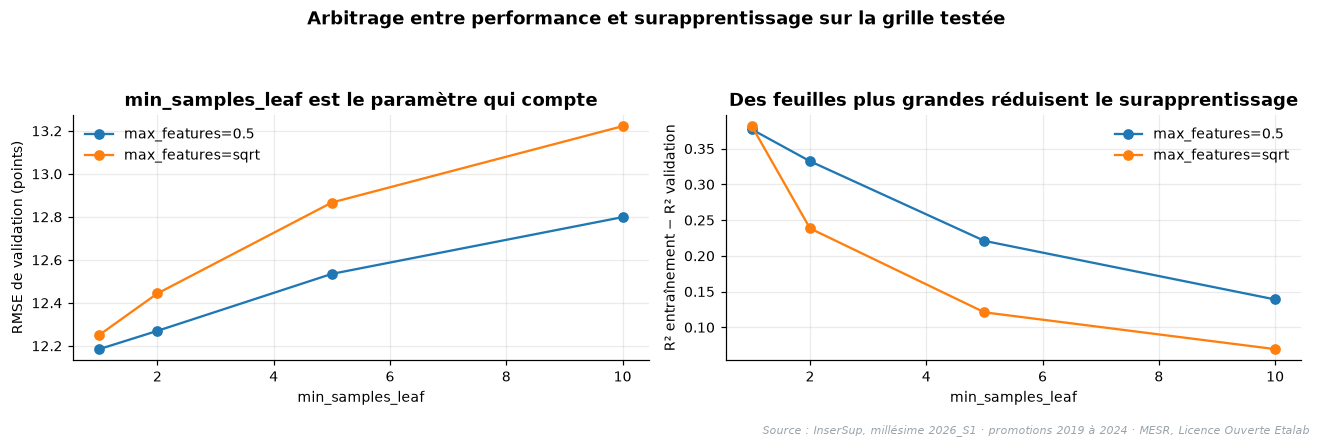

In [4]:
figure, axes = plt.subplots(1, 2, figsize=(12, 3.8))

pivot = tableau.pivot_table(index='min_samples_leaf', columns='max_features',
                            values='RMSE validation', aggfunc='min')
for colonne in pivot.columns:
    axes[0].plot(pivot.index, pivot[colonne], marker='o', label=f'max_features={colonne}')
axes[0].set_xlabel('min_samples_leaf')
axes[0].set_ylabel('RMSE de validation (points)')
axes[0].set_title("min_samples_leaf est le paramètre qui compte")
axes[0].legend(frameon=False)

pivot_ecart = tableau.pivot_table(index='min_samples_leaf', columns='max_features',
                                  values='écart train − validation', aggfunc='mean')
for colonne in pivot_ecart.columns:
    axes[1].plot(pivot_ecart.index, pivot_ecart[colonne], marker='o',
                 label=f'max_features={colonne}')
axes[1].set_xlabel('min_samples_leaf')
axes[1].set_ylabel('R² entraînement − R² validation')
axes[1].set_title('Des feuilles plus grandes réduisent le surapprentissage')
axes[1].legend(frameon=False)

figure.suptitle("Arbitrage entre performance et surapprentissage sur la grille testée",
                fontsize=12, fontweight='bold')
figure.tight_layout(rect=(0, 0, 1, 0.90))
annoter_source()
plt.savefig(FIGURE_PATH / 'fig13_grille_hyperparametres.png')
plt.show()

### Choix final : la règle à un écart-type

La meilleure configuration de la grille n'est pas forcément celle qu'il faut retenir. Son
avance sur les suivantes doit d'abord être **plus grande que le bruit de mesure**, que
l'écart-type entre plis quantifie.

On applique donc la règle classique dite « à un écart-type » : parmi toutes les
configurations dont la RMSE est à moins d'un écart-type de la meilleure, on garde **la plus
simple**. Une configuration plus simple généralise mieux, s'explique mieux, et produit un
fichier de modèle plus léger.

In [5]:
meilleure = tableau.loc[tableau['rang'].idxmin()]
seuil = meilleure['RMSE validation'] + meilleure['RMSE (écart-type)']
equivalentes = tableau[tableau['RMSE validation'] <= seuil]

# Le plus simple : feuilles les plus grandes d'abord, puis le moins d'arbres.
retenue = equivalentes.sort_values(
    ['min_samples_leaf', 'n_estimators'], ascending=[False, True]).iloc[0]

PARAMETRES_RETENUS = {
    'n_estimators': int(retenue['n_estimators']),
    'max_features': retenue['max_features'],
    'min_samples_leaf': int(retenue['min_samples_leaf']),
}

print(f"Meilleure RMSE : {meilleure['RMSE validation']:.3f} "
      f"(± {meilleure['RMSE (écart-type)']:.3f} entre plis)")
print(f'Seuil à un écart-type : {seuil:.3f}')
print(f'{len(equivalentes)} configurations sur {len(tableau)} sont statistiquement '
      f'équivalentes à la meilleure.')
print()
print('Configuration retenue, la plus simple parmi elles :')
for parametre, valeur in PARAMETRES_RETENUS.items():
    print(f'  {parametre} = {valeur}')
print()
print(f"Coût du choix : {retenue['RMSE validation'] - meilleure['RMSE validation']:+.3f} "
      f"point de RMSE, soit "
      f"{(retenue['RMSE validation'] - meilleure['RMSE validation']) / meilleure['RMSE (écart-type)']:.2f} "
      f"écart-type.")
print(f"Bénéfice : écart train − validation ramené de "
      f"{meilleure['écart train − validation']:.3f} à {retenue['écart train − validation']:.3f}.")
equivalentes[['n_estimators', 'max_features', 'min_samples_leaf', 'RMSE validation',
              'R² validation', 'écart train − validation']]

Meilleure RMSE : 12.185 (± 0.182 entre plis)
Seuil à un écart-type : 12.367
6 configurations sur 16 sont statistiquement équivalentes à la meilleure.

Configuration retenue, la plus simple parmi elles :
  n_estimators = 200
  max_features = 0.5
  min_samples_leaf = 2

Coût du choix : +0.096 point de RMSE, soit 0.53 écart-type.
Bénéfice : écart train − validation ramené de 0.377 à 0.332.


,n_estimators,max_features,min_samples_leaf,RMSE validation,R² validation,écart train − validation
0,200,sqrt,1,12.269,0.557,0.382
1,400,sqrt,1,12.251,0.559,0.381
8,200,0.5,1,12.198,0.562,0.377
9,400,0.5,1,12.185,0.563,0.377
10,200,0.5,2,12.281,0.557,0.332
11,400,0.5,2,12.270,0.557,0.333


### Ce que la grille dit, et ce qu'elle ne dit pas

La grille reste volontairement petite : 16 configurations. Elle donne un **bon réglage de
travail**, pas une preuve d'optimalité. Explorer davantage exposerait à un second risque,
celui de choisir une configuration qui doit sa première place au hasard d'un découpage
plutôt qu'à une vraie supériorité : c'est pourquoi l'écart-type entre plis est reporté à
côté de chaque score.

## 2. Diagnostic du modèle retenu

Avant d'ouvrir le jeu de test, on vérifie ce que la configuration retenue a gagné, et ce
qu'elle a coûté, par rapport à la configuration de départ de l'étape 4.

In [6]:
configurations = {
    "Étape 4 (n=200, leaf=2, max_features par défaut)": RandomForestRegressor(
        n_estimators=200, min_samples_leaf=2, random_state=42, n_jobs=-1),
    'Meilleure de la grille': RandomForestRegressor(
        random_state=42, n_jobs=-1,
        **{parametre.replace('modele__', ''): valeur
           for parametre, valeur in recherche.best_params_.items()}),
    'Retenue (règle à un écart-type)': RandomForestRegressor(
        random_state=42, n_jobs=-1, **PARAMETRES_RETENUS),
}

evolution = []
for nom, modele in configurations.items():
    scores = cross_validate(creer_pipeline(modele), X_train, y_train, cv=CV,
                            scoring={'mae': 'neg_mean_absolute_error',
                                     'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'},
                            return_train_score=True, n_jobs=-1)
    evolution.append({
        'configuration': nom,
        'MAE validation': round(-scores['test_mae'].mean(), 3),
        'RMSE validation': round(-scores['test_rmse'].mean(), 3),
        'R² validation': round(scores['test_r2'].mean(), 3),
        'R² entraînement': round(scores['train_r2'].mean(), 3),
        'écart train − validation': round(
            scores['train_r2'].mean() - scores['test_r2'].mean(), 3),
    })
evolution = pd.DataFrame(evolution).set_index('configuration')
evolution

,MAE validation,RMSE validation,R² validation,R² entraînement,écart train − validation
configuration,,,,,
"Étape 4 (n=200, leaf=2, max_features par défaut)",9.495,12.365,0.550,0.899,0.349
Meilleure de la grille,9.365,12.185,0.563,0.940,0.377
Retenue (règle à un écart-type),9.438,12.281,0.557,0.889,0.333


## 3. Évaluation finale sur le jeu de test

C'est **la seule et unique ouverture du jeu de test** de tout le projet. Le modèle est
entraîné sur l'intégralité du jeu d'apprentissage avec les hyperparamètres retenus, puis
appliqué au test.

Une baseline est également entraînée et évaluée sur le même test : sans elle, un chiffre
de MAE ne veut rien dire.

In [7]:
modele_final = creer_pipeline(configurations['Retenue (règle à un écart-type)'])
modele_final.fit(X_train, y_train)
predictions = modele_final.predict(X_test)

reference = creer_pipeline(DummyRegressor(strategy='mean'))
reference.fit(X_train, y_train)
predictions_reference = reference.predict(X_test)


def mesurer(vraies_valeurs, valeurs_predites):
    return {
        'MAE': round(mean_absolute_error(vraies_valeurs, valeurs_predites), 3),
        'RMSE': round(mean_squared_error(vraies_valeurs, valeurs_predites) ** 0.5, 3),
        'R²': round(r2_score(vraies_valeurs, valeurs_predites), 3),
    }


resultat_test = pd.DataFrame({
    'Référence naïve': mesurer(y_test, predictions_reference),
    'Forêt aléatoire optimisée': mesurer(y_test, predictions),
})
resultat_test['gain'] = (resultat_test['Forêt aléatoire optimisée']
                         - resultat_test['Référence naïve']).round(3)

erreurs = np.abs(y_test.to_numpy() - predictions)
erreurs_reference = np.abs(y_test.to_numpy() - predictions_reference)

print(f"Sur les {len(y_test)} formations du jeu de test :")
print(f"  · erreur moyenne du modèle : {erreurs.mean():.2f} points de taux d'emploi")
print(f"  · erreur moyenne de la référence : {erreurs_reference.mean():.2f} points")
print(f"  · réduction de l'erreur : "
      f"{100 * (1 - erreurs.mean() / erreurs_reference.mean()):.0f} %")
print(f"  · formations prédites à moins de 5 points près : "
      f"{100 * (erreurs <= 5).mean():.0f} % (contre "
      f"{100 * (erreurs_reference <= 5).mean():.0f} % pour la référence)")
print(f"  · formations ratées de plus de 15 points : {int((erreurs > 15).sum())} "
      f"(contre {int((erreurs_reference > 15).sum())})")
resultat_test

Sur les 3413 formations du jeu de test :
  · erreur moyenne du modèle : 9.58 points de taux d'emploi
  · erreur moyenne de la référence : 15.07 points
  · réduction de l'erreur : 36 %
  · formations prédites à moins de 5 points près : 33 % (contre 20 % pour la référence)
  · formations ratées de plus de 15 points : 697 (contre 1509)


,Référence naïve,Forêt aléatoire optimisée,gain
MAE,15.069,9.579,-5.490
RMSE,18.523,12.373,-6.150
R²,-0.000,0.554,0.554


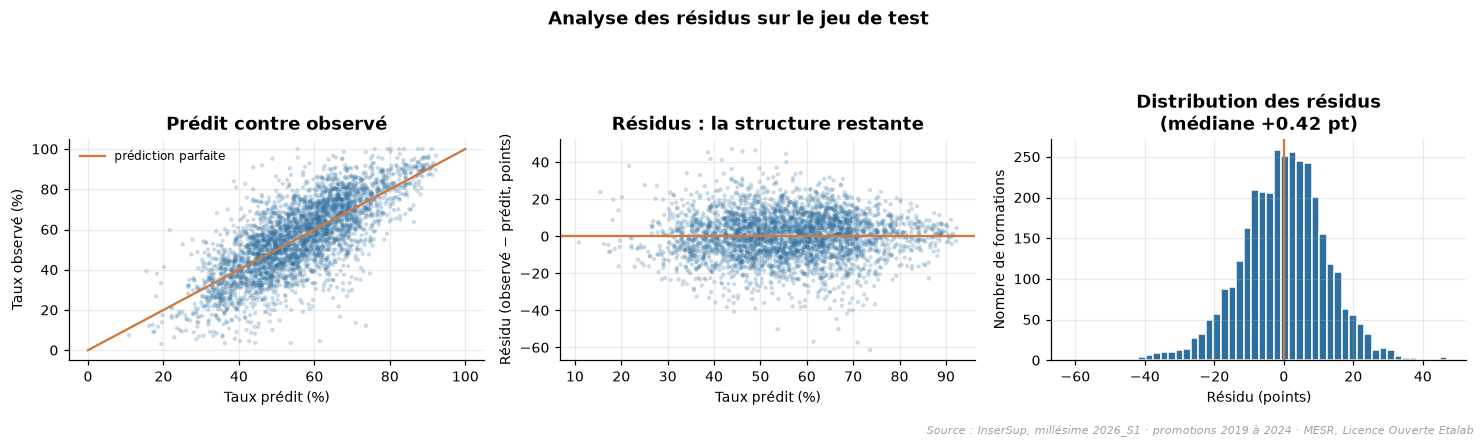

Pente de la droite résidus ~ prédictions : +0.015
Résidu moyen : -0.014 point  ·  écart-type : 12.37 points


In [8]:
residus = y_test.to_numpy() - predictions

figure, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))

axes[0].scatter(predictions, y_test, s=8, alpha=0.25, color=COULEUR, edgecolor='none')
limites = [0, 100]
axes[0].plot(limites, limites, color=COULEUR_ALT, linewidth=1.5, label='prédiction parfaite')
axes[0].set_xlabel('Taux prédit (%)')
axes[0].set_ylabel('Taux observé (%)')
axes[0].set_title('Prédit contre observé')
axes[0].legend(frameon=False, fontsize=8)

axes[1].scatter(predictions, residus, s=8, alpha=0.25, color=COULEUR, edgecolor='none')
axes[1].axhline(0, color=COULEUR_ALT, linewidth=1.5)
axes[1].set_xlabel('Taux prédit (%)')
axes[1].set_ylabel('Résidu (observé − prédit, points)')
axes[1].set_title('Résidus : la structure restante')

axes[2].hist(residus, bins=50, color=COULEUR, edgecolor='white')
axes[2].axvline(0, color=COULEUR_ALT, linewidth=1.5)
axes[2].set_xlabel('Résidu (points)')
axes[2].set_ylabel('Nombre de formations')
axes[2].set_title(f'Distribution des résidus\n(médiane {np.median(residus):+.2f} pt)')

figure.suptitle("Analyse des résidus sur le jeu de test", fontsize=12, fontweight='bold')
figure.tight_layout(rect=(0, 0, 1, 0.90))
annoter_source()
plt.savefig(FIGURE_PATH / 'fig14_residus.png')
plt.show()

pente = np.polyfit(predictions, residus, 1)[0]
print(f'Pente de la droite résidus ~ prédictions : {pente:+.3f}')
print(f'Résidu moyen : {residus.mean():+.3f} point  ·  écart-type : {residus.std():.2f} points')

**Lecture des résidus.** Le nuage « prédit contre observé » est nettement plus resserré
que ne le serait une prédiction constante, mais il reste aplati par rapport à la
diagonale : le modèle sous-estime les taux très élevés et surestime les taux très bas.

C'est le comportement attendu d'un modèle d'ensemble. Une forêt prédit la moyenne des
feuilles atteintes, et une moyenne est par construction attirée vers le centre de la
distribution. La conséquence pratique est directe et doit être annoncée : **le modèle est
le moins fiable exactement sur les formations extrêmes**, celles qui insèrent très bien ou
très mal, c'est-à-dire souvent celles qui intéressent le plus un responsable pédagogique.

La pente de la droite des résidus quantifie cet effet ; le résidu moyen proche de zéro
confirme en revanche l'absence de biais global.

## 4. Interprétation : qu'a appris le modèle ?

Deux mesures d'importance sont calculées, parce qu'elles ne mesurent pas la même chose.

L'**importance par impureté** (`feature_importances_`) compte combien chaque variable a
réduit l'erreur lors des coupes. Elle est gratuite, mais elle favorise mécaniquement les
variables à nombreuses valeurs distinctes.

L'**importance par permutation** mesure de combien le score se dégrade quand on mélange
au hasard une colonne. Elle est plus fiable et plus coûteuse. Elle est calculée ici sur le
jeu de test **après** que le score final a été reporté : aucune décision de modélisation
n'en découle, elle ne sert qu'à comprendre.

In [9]:
noms_encodes = modele_final.named_steps['pretraitement'].get_feature_names_out()
noms_encodes = [nom.split('__', 1)[-1] for nom in noms_encodes]
importances_impurete = pd.Series(
    modele_final.named_steps['modele'].feature_importances_, index=noms_encodes)

# On regroupe les colonnes one-hot sous le nom de leur variable d'origine.
def variable_origine(nom_encode):
    for variable in sorted(FEATURES, key=len, reverse=True):
        if nom_encode == variable or nom_encode.startswith(variable + '_'):
            return variable
    return nom_encode


importance_par_variable = (importances_impurete
                           .groupby(variable_origine)
                           .sum()
                           .sort_values(ascending=False))

permutation = permutation_importance(modele_final, X_test, y_test, n_repeats=5,
                                     random_state=42, scoring='neg_root_mean_squared_error',
                                     n_jobs=1)
importance_permutation = pd.Series(permutation.importances_mean, index=FEATURES)

comparaison_importance = pd.DataFrame({
    'importance par impureté': importance_par_variable.round(4),
    'importance par permutation (RMSE)': importance_permutation.round(4),
}).sort_values('importance par permutation (RMSE)', ascending=False)
comparaison_importance

,importance par impureté,importance par permutation (RMSE)
est_diplome_professionnalisant,0.1238,3.0281
ratio_poursuite,0.1211,1.5709
nb_etablissements_par_diplome,0.0703,1.2207
Domaine disciplinaire,0.0462,0.8114
Type de diplôme,0.0631,0.7919
anciennete_promotion,0.0514,0.7722
Académie,0.0628,0.4647
6-Nombre de poursuivants - 6 mois après le diplôme,0.0593,0.4070
Secteur disciplinaire,0.0537,0.3514
nb_formations_etablissement,0.0471,0.3458


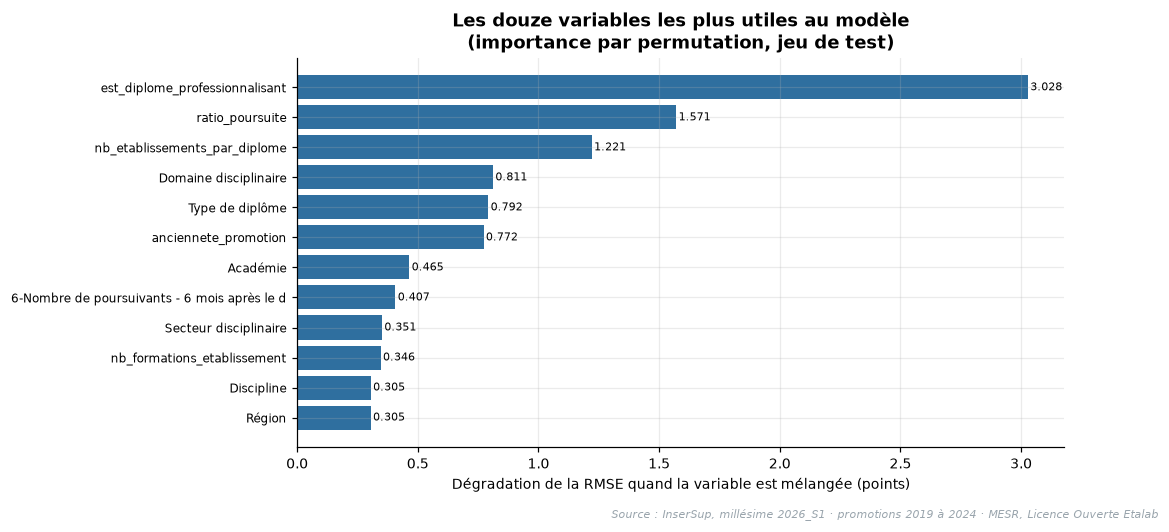

In [10]:
sommet = comparaison_importance.head(12).sort_values('importance par permutation (RMSE)')
positions = np.arange(len(sommet))

figure, axes = plt.subplots(figsize=(9, 4.6))
axes.barh(positions, sommet['importance par permutation (RMSE)'], color=COULEUR)
axes.set_yticks(positions)
axes.set_yticklabels([nom[:44] for nom in sommet.index], fontsize=8)
axes.set_xlabel('Dégradation de la RMSE quand la variable est mélangée (points)')
axes.set_title('Les douze variables les plus utiles au modèle\n'
               '(importance par permutation, jeu de test)')
for position, valeur in enumerate(sommet['importance par permutation (RMSE)']):
    axes.text(valeur + 0.01, position, f'{valeur:.3f}', va='center', fontsize=7.5)
annoter_source()
plt.savefig(FIGURE_PATH / 'fig15_importance_variables.png')
plt.show()

### Confrontation avec l'EDA de l'étape 2

L'étape 2 avait formulé cinq hypothèses. Le modèle permet de les trancher, et deux d'entre
elles ne résistent pas.

| Hypothèse de l'étape 2 | Verdict |
|---|---|
| 1. Le ratio de poursuite d'études est le prédicteur numérique le plus prometteur | **Confirmée** : 2e des deux classements d'importance |
| 2. Le secteur disciplinaire doit primer sur le domaine | **Infirmée** : le modèle s'appuie sur le domaine, pas sur le secteur |
| 3. La promotion apporte un effet de niveau, pas une tendance | **Nuancée** : c'est la forme ordonnée qui sert, pas l'encodage par année |
| 4. L'erreur sera plus forte sur les petits effectifs | Tranchée en section 5 |
| 5. Un $R^2$ autour de 0,5 est un plafond réaliste | **Confirmée** : 0,554 sur le test |

**Hypothèse 2, infirmée.** L'EDA avait mesuré un eta² de 0,194 pour le secteur
disciplinaire contre 0,083 pour le domaine, et en avait conclu qu'il fallait donner au
modèle le niveau fin. L'importance par permutation dit l'inverse : le domaine ressort à
0,81, le secteur à 0,35.

L'explication n'est pas que l'EDA avait tort, mais que les deux variables sont
**redondantes** : le domaine est l'agrégat du secteur. Mélanger l'une laisse l'autre
disponible, et le modèle compense. L'importance par permutation sous-estime donc
systématiquement les variables redondantes, et le modèle a préféré couper sur les 4
modalités du domaine, statistiquement plus robustes, que sur les 49 du secteur. La
conclusion pratique reste de fournir les deux, mais l'affirmation « le secteur prime »
n'est pas vérifiée.

**Hypothèse 3, nuancée.** `anciennete_promotion` obtient 0,77 et `Promotion` 0,03, alors
que les deux portent exactement la même information temporelle. Le modèle a choisi la
**forme ordonnée** : une seule coupe sur un axe continu vaut mieux que six indicatrices
séparées. C'est la justification a posteriori de la redondance volontaire introduite à
l'étape 3.

### Le résultat le plus instructif : la corrélation linéaire ne dit pas tout

`nb_etablissements_par_diplome` avait une corrélation de Pearson de **0,02** avec la cible
à l'étape 3, ce qui la rendait apparemment inutile. Elle ressort pourtant parmi les
variables les plus utiles au modèle.

L'explication tient à la nature de l'information : le nombre d'établissements délivrant un
diplôme sépare les diplômes nationaux très répandus des diplômes propres à un
établissement, et cette distinction n'agit pas de façon monotone sur le taux d'emploi. Une
corrélation de Pearson ne mesure qu'un lien **linéaire** ; une forêt exploite des seuils et
des interactions qu'aucun coefficient de corrélation ne capte.

La leçon est méthodologique : **écarter une variable sur sa seule corrélation linéaire
aurait été une erreur.** À l'inverse, `tranche_effectif` et `promotion_choc_sanitaire`
figurent bien en bas des deux classements : le découpage en tranches n'apporte rien que
`taille_formation` ne porte déjà, et l'indicateur 2020 fait doublon avec l'encodage de
`Promotion`. Une partie du feature engineering n'a donc pas servi, et le dire vaut mieux
que de le masquer.

## 5. Analyse des erreurs par groupe

Une erreur moyenne globale cache des disparités. On regarde donc où le modèle se trompe,
en ne commentant que les groupes suffisamment nombreux pour que la mesure ait un sens.

In [11]:
SEUIL_GROUPE = 30

analyse = X_test.copy()
analyse['erreur_absolue'] = np.abs(y_test.to_numpy() - predictions)
analyse['residu'] = y_test.to_numpy() - predictions
analyse['cible'] = y_test.to_numpy()

groupes = {}
for colonne in ['Promotion', 'Type de diplôme', 'tranche_effectif', 'Domaine disciplinaire']:
    resume = (analyse.groupby(colonne)
              .agg(formations=('erreur_absolue', 'size'),
                   MAE=('erreur_absolue', 'mean'),
                   biais_moyen=('residu', 'mean'))
              .query(f'formations >= {SEUIL_GROUPE}')
              .sort_values('MAE', ascending=False)
              .round(2))
    groupes[colonne] = resume
    print(f'--- MAE par {colonne} (groupes de {SEUIL_GROUPE} formations minimum) ---')
    print(resume.to_string())
    print()

--- MAE par Promotion (groupes de 30 formations minimum) ---
           formations    MAE  biais_moyen
Promotion                                
2020              544  10.44        -0.89
2019              529   9.99        -0.11
2023              553   9.61        -0.01
2024              607   9.53        -0.18
2021              566   9.03         0.62
2022              614   8.99         0.42

--- MAE par Type de diplôme (groupes de 30 formations minimum) ---
                                          formations    MAE  biais_moyen
Type de diplôme                                                         
Master LMD                                      1648  10.06        -0.02
Licence professionnelle                          410  10.00        -0.20
Diplôme d'ingénieurs                             510   9.32        -0.56
Licence générale                                 484   8.74         0.43
Diplôme visé niveau bac + 5 grade master         157   8.29        -0.73
Bachelor universitaire d

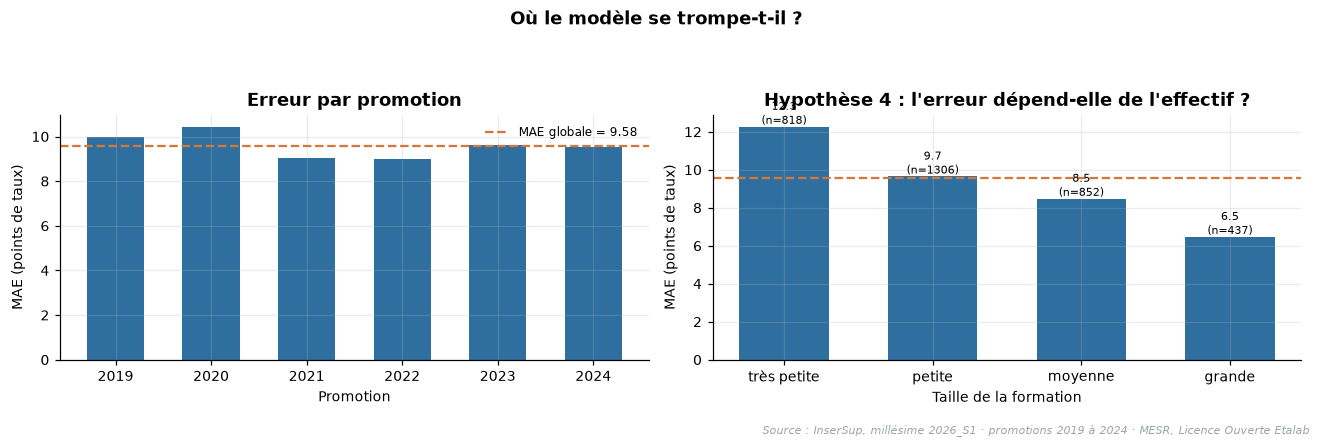

In [12]:
figure, axes = plt.subplots(1, 2, figsize=(12, 3.8))

par_promotion = groupes['Promotion'].sort_index()
axes[0].bar(par_promotion.index.astype(str), par_promotion['MAE'], color=COULEUR, width=0.6)
axes[0].axhline(erreurs.mean(), color=COULEUR_ALT, linestyle='--',
                label=f'MAE globale = {erreurs.mean():.2f}')
axes[0].set_xlabel('Promotion')
axes[0].set_ylabel('MAE (points de taux)')
axes[0].set_title('Erreur par promotion')
axes[0].legend(frameon=False, fontsize=8)

par_taille = groupes['tranche_effectif'].reindex(
    ['très petite (≤ 25)', 'petite (26-45)', 'moyenne (46-90)', 'grande (> 90)']).dropna()
axes[1].bar(range(len(par_taille)), par_taille['MAE'], color=COULEUR, width=0.6)
axes[1].set_xticks(range(len(par_taille)))
axes[1].set_xticklabels([nom.split(' (')[0] for nom in par_taille.index])
axes[1].axhline(erreurs.mean(), color=COULEUR_ALT, linestyle='--')
axes[1].set_xlabel('Taille de la formation')
axes[1].set_ylabel('MAE (points de taux)')
axes[1].set_title("Hypothèse 4 : l'erreur dépend-elle de l'effectif ?")
for position, (valeur, effectif) in enumerate(zip(par_taille['MAE'], par_taille['formations'])):
    axes[1].text(position, valeur + 0.15, f'{valeur:.1f}\n(n={effectif:.0f})',
                 ha='center', fontsize=7.5)

figure.suptitle("Où le modèle se trompe-t-il ?", fontsize=12, fontweight='bold')
figure.tight_layout(rect=(0, 0, 1, 0.90))
annoter_source()
plt.savefig(FIGURE_PATH / 'fig16_erreurs_par_groupe.png')
plt.show()

## 6. Audit de fuite et robustesse temporelle

Le découpage aléatoire pose un problème que le score seul ne révèle pas. Une même
formation apparaît jusqu'à six fois dans le jeu, une fois par promotion. Un découpage au
hasard place donc très probablement certaines de ses promotions dans l'entraînement et
d'autres dans le test.

Ce n'est **pas une fuite de cible** : la valeur à prédire du test n'a jamais servi à
ajuster le modèle. C'est un **biais de validation** : le score aléatoire mesure surtout la
capacité à prédire une nouvelle promotion d'une formation déjà connue, ce qui est plus
facile que de prédire une formation inconnue.

On chiffre d'abord ce recouvrement, puis on mesure ce que devient le score dans le
scénario réellement visé : prédire une promotion future à partir des promotions passées.

In [13]:
COLONNES_FORMATION = [CODE_UAI, CODE_SISE]
identite_formation = df[COLONNES_FORMATION].astype(str).agg('|'.join, axis=1)
formations_train = set(identite_formation.loc[X_train.index])
formations_test = identite_formation.loc[X_test.index]

deja_vues = formations_test.isin(formations_train)
print('Recouvrement du découpage aléatoire :')
print(f'  · formations distinctes en apprentissage : {len(formations_train)}')
print(f'  · lignes de test dont la formation a déjà été vue : '
      f'{int(deja_vues.sum())} / {len(X_test)} ({100 * deja_vues.mean():.1f} %)')
print()

erreur_deja_vues = np.abs(y_test.to_numpy() - predictions)[deja_vues.to_numpy()]
erreur_inconnues = np.abs(y_test.to_numpy() - predictions)[~deja_vues.to_numpy()]
print(f'  · MAE sur les formations déjà vues : {erreur_deja_vues.mean():.2f} points '
      f'({len(erreur_deja_vues)} lignes)')
print(f'  · MAE sur les formations inconnues : {erreur_inconnues.mean():.2f} points '
      f'({len(erreur_inconnues)} lignes)')
print(f'  · surcoût pour une formation inconnue : '
      f'{erreur_inconnues.mean() - erreur_deja_vues.mean():+.2f} point')

Recouvrement du découpage aléatoire :
  · formations distinctes en apprentissage : 4638
  · lignes de test dont la formation a déjà été vue : 3073 / 3413 (90.0 %)

  · MAE sur les formations déjà vues : 9.39 points (3073 lignes)
  · MAE sur les formations inconnues : 11.28 points (340 lignes)
  · surcoût pour une formation inconnue : +1.89 point


In [14]:
# Scénario réel : entraîner sur le passé, prédire l'avenir.
masque_passe = df['Promotion'] <= 2022
masque_futur = df['Promotion'] >= 2023

modele_temporel = creer_pipeline(configurations['Retenue (règle à un écart-type)'])
modele_temporel.fit(df.loc[masque_passe, FEATURES], df.loc[masque_passe, TARGET])
predictions_temporelles = modele_temporel.predict(df.loc[masque_futur, FEATURES])

reference_temporelle = creer_pipeline(DummyRegressor(strategy='mean'))
reference_temporelle.fit(df.loc[masque_passe, FEATURES], df.loc[masque_passe, TARGET])

scenarios = pd.DataFrame({
    'Découpage aléatoire (test 2019-2024)': mesurer(y_test, predictions),
    'Découpage temporel (train 2019-2022, test 2023-2024)': mesurer(
        df.loc[masque_futur, TARGET], predictions_temporelles),
    'Référence naïve sur le découpage temporel': mesurer(
        df.loc[masque_futur, TARGET],
        reference_temporelle.predict(df.loc[masque_futur, FEATURES])),
}).T

print(f'Apprentissage temporel : {int(masque_passe.sum())} lignes (promotions 2019-2022)')
print(f'Test temporel : {int(masque_futur.sum())} lignes (promotions 2023-2024)')
scenarios

Apprentissage temporel : 11258 lignes (promotions 2019-2022)
Test temporel : 5807 lignes (promotions 2023-2024)


,MAE,RMSE,R²
Découpage aléatoire (test 2019-2024),9.579,12.373,0.554
"Découpage temporel (train 2019-2022, test 2023-2024)",9.853,12.922,0.458
Référence naïve sur le découpage temporel,14.008,17.569,-0.002


**Les deux scores mesurent deux choses différentes, et doivent être présentés ensemble.**

Le score aléatoire répond à : « connaissant le paysage 2019-2024, sais-je estimer une
formation dont je n'ai pas la mesure ? » Le score temporel répond à : « connaissant le
passé, sais-je prévoir l'avenir ? »

Le second est plus faible, et c'est normal. La promotion 2020 fausse en partie
l'apprentissage, et surtout le modèle n'a aucun moyen de connaître la conjoncture des
années qu'il doit prédire : l'EDA avait montré à la question 5 que le niveau d'insertion
bouge de plus de 13 points d'une promotion à l'autre pour des raisons extérieures aux
formations.

**C'est le score temporel qu'il faut annoncer** si le modèle est présenté comme un outil
de prévision. Le score aléatoire vaut pour de l'imputation : estimer une formation non
publiée d'une année déjà observée.

## 7. Limites et biais

**Ce que le modèle prédit.** Un taux agrégé de formation, jamais l'employabilité d'un
individu. Une formation à 70 % d'insertion ne dit rien de ce qui arrivera à un étudiant
donné.

**Erreur moyenne.** Environ 9,5 points de taux d'emploi. Sur une formation annoncée à
60 %, la réalité se situe le plus souvent entre 50 % et 70 %. C'est utilisable pour
comparer des familles de formations, pas pour classer deux formations proches.

**Erreur très inégale selon la taille.** L'analyse par tranche d'effectif montre un rapport
de près de deux entre les plus petites formations et les plus grandes. Sur une formation de
moins de 25 sortants, la prédiction est nettement moins fiable que la moyenne annoncée.

**Biais de sélection.** Le seuil de publication de 20 sortants exclut structurellement les
petites formations. Le modèle n'a jamais vu de formation de 10 diplômés et n'a aucune
raison d'être fiable sur ce cas.

**Biais de représentation.** Les régions et les disciplines sont inégalement représentées.
Les régions à faible effectif de formations sont mécaniquement moins bien apprises.

**Ce que le modèle ne peut pas dire.** `Genre`, `Nationalité` et `Régime d'inscription`
ne font pas partie du jeu de modélisation, qui est agrégé sur ces dimensions. Le modèle ne
peut donc **ni** produire ni écarter une conclusion sur des disparités de genre ou de
nationalité. La question 3 de l'EDA a d'ailleurs montré qu'une comparaison naïve sur ces
variables donne un résultat de signe opposé à une comparaison à formation égale : toute
analyse d'équité demanderait de reconstruire le jeu au niveau démographique et de mesurer
la performance par sous-groupe.

**Risque d'usage.** Un tel modèle appliqué à une décision d'orientation ou d'allocation de
moyens reproduirait les écarts existants entre disciplines et entre territoires, en leur
donnant l'apparence d'une prédiction objective. Son usage raisonnable est descriptif et
exploratoire, pas prescriptif.

**Erreur non homogène.** Le modèle est moins précis sur les formations aux taux extrêmes
(effet de régression vers la moyenne montré en section 3) et sur les promotions
atypiques.

## 8. Livraison : pipeline sauvegardée et prédiction sur une donnée brute

La pipeline complète est sauvegardée : elle contient l'encodage **et** le modèle. Un
utilisateur n'a donc rien à réimplémenter.

Comme dix des dix-neuf variables sont construites à l'étape 3, on sauvegarde aussi le
**référentiel** nécessaire à leur calcul, et une fonction qui transforme une ligne telle
que la source la publie en une ligne prête pour le modèle. C'est ce couple qui rend le
livrable réellement utilisable.

In [15]:
# Référentiel construit sur le seul jeu d'apprentissage.
train_complet = df.loc[X_train.index]
REFERENTIEL = {
    'taille_mediane_secteur': train_complet.groupby('Secteur disciplinaire')[SORTANTS]
                                           .median().to_dict(),
    'nb_formations_etablissement': train_complet.groupby(CODE_UAI)[CODE_SISE]
                                                .nunique().to_dict(),
    'nb_etablissements_par_diplome': train_complet.groupby(CODE_SISE)[CODE_UAI]
                                                  .nunique().to_dict(),
    'sortants_etablissement': train_complet.groupby(CODE_UAI)[SORTANTS].sum().to_dict(),
    'defauts': {
        'taille_mediane_secteur': float(train_complet[SORTANTS].median()),
        'nb_formations_etablissement': float(
            train_complet.groupby(CODE_UAI)[CODE_SISE].nunique().median()),
        'nb_etablissements_par_diplome': float(
            train_complet.groupby(CODE_SISE)[CODE_UAI].nunique().median()),
        'sortants_etablissement': float(
            train_complet.groupby(CODE_UAI)[SORTANTS].sum().median()),
    },
    'diplomes_professionnalisants': ['Licence professionnelle', 'Master MEEF',
                                     "Diplôme d'ingénieurs",
                                     'Bachelor universitaire de technologie'],
    'millesime': 2026,
}


def preparer_ligne_brute(ligne, referentiel=REFERENTIEL):
    """Transforme une ligne telle que publiée par INSERSUP en entrée du modèle."""
    defauts = referentiel['defauts']
    sortants = float(ligne[SORTANTS])
    poursuivants = float(ligne[POURSUIVANTS])
    taille = sortants + poursuivants
    total_etablissement = referentiel['sortants_etablissement'].get(
        ligne[CODE_UAI], defauts['sortants_etablissement'])

    if sortants <= 25:
        tranche = 'très petite (≤ 25)'
    elif sortants <= 45:
        tranche = 'petite (26-45)'
    elif sortants <= 90:
        tranche = 'moyenne (46-90)'
    else:
        tranche = 'grande (> 90)'

    preparee = {
        'Région': ligne['Région'], 'Académie': ligne['Académie'],
        'Type de diplôme': ligne['Type de diplôme'],
        'Domaine disciplinaire': ligne['Domaine disciplinaire'],
        'Discipline': ligne['Discipline'],
        'Secteur disciplinaire': ligne['Secteur disciplinaire'],
        'Promotion': int(ligne['Promotion']),
        'tranche_effectif': tranche,
        SORTANTS: sortants,
        POURSUIVANTS: poursuivants,
        'anciennete_promotion': referentiel['millesime'] - int(ligne['Promotion']),
        'promotion_choc_sanitaire': int(int(ligne['Promotion']) == 2020),
        'est_diplome_professionnalisant': int(
            ligne['Type de diplôme'] in referentiel['diplomes_professionnalisants']),
        'taille_formation': taille,
        'ratio_poursuite': round(poursuivants / taille, 4) if taille else 0.0,
        'taille_mediane_secteur': referentiel['taille_mediane_secteur'].get(
            ligne['Secteur disciplinaire'], defauts['taille_mediane_secteur']),
        'nb_formations_etablissement': referentiel['nb_formations_etablissement'].get(
            ligne[CODE_UAI], defauts['nb_formations_etablissement']),
        'part_sortants_etablissement': round(sortants / total_etablissement, 4),
        'nb_etablissements_par_diplome': referentiel['nb_etablissements_par_diplome'].get(
            ligne[CODE_SISE], defauts['nb_etablissements_par_diplome']),
    }
    return pd.DataFrame([preparee])[FEATURES]


FICHIER_MODELE = MODEL_PATH / 'modele_final_random_forest.joblib'
# compress=3 : une forêt non compressée dépasse la centaine de mégaoctets, ce qui rend
# le livrable impraticable à partager.
joblib.dump({'pipeline': modele_final, 'referentiel': REFERENTIEL, 'features': FEATURES,
             'cible': TARGET, 'metriques_test': mesurer(y_test, predictions)},
            FICHIER_MODELE, compress=3)
print('Modèle sauvegardé :', FICHIER_MODELE.relative_to(PROJECT_PATH))
print('Taille du fichier :', round(FICHIER_MODELE.stat().st_size / 1024**2, 1), 'Mo')

Modèle sauvegardé : modeles/modele_final_random_forest.joblib
Taille du fichier : 29.6 Mo


In [16]:
# Rechargement complet, comme le ferait un utilisateur qui reçoit seulement le fichier.
livrable = joblib.load(FICHIER_MODELE)
pipeline_rechargee = livrable['pipeline']

ligne_brute = {
    'Région': 'Bretagne',
    'Académie': 'Rennes',
    'Type de diplôme': 'Licence professionnelle',
    'Domaine disciplinaire': 'Sciences, technologies, santé',
    'Discipline': 'Sciences fondamentales et applications',
    'Secteur disciplinaire': 'Informatique',
    'Promotion': 2024,
    CODE_UAI: '0350936C',
    CODE_SISE: '99999',          # diplôme inconnu du référentiel : le repli doit fonctionner
    SORTANTS: 48,
    POURSUIVANTS: 6,
}

ligne_preparee = preparer_ligne_brute(ligne_brute, livrable['referentiel'])
prediction = float(pipeline_rechargee.predict(ligne_preparee)[0])

print('Donnée brute soumise :')
for cle, valeur in ligne_brute.items():
    print(f'  {cle} : {valeur}')
print()
print(f"Prédiction : {prediction:.1f} % de taux d'emploi salarié à 6 mois")
print(f"Intervalle indicatif à ± la MAE de test : "
      f"{prediction - resultat_test.loc['MAE', 'Forêt aléatoire optimisée']:.1f} % à "
      f"{prediction + resultat_test.loc['MAE', 'Forêt aléatoire optimisée']:.1f} %")
print()
print('Variables reconstruites automatiquement à partir du référentiel :')
print(ligne_preparee[['tranche_effectif', 'ratio_poursuite', 'taille_mediane_secteur',
                      'nb_formations_etablissement', 'nb_etablissements_par_diplome',
                      'est_diplome_professionnalisant']].to_string(index=False))

Donnée brute soumise :
  Région : Bretagne
  Académie : Rennes
  Type de diplôme : Licence professionnelle
  Domaine disciplinaire : Sciences, technologies, santé
  Discipline : Sciences fondamentales et applications
  Secteur disciplinaire : Informatique
  Promotion : 2024
  Code UAI de l'établissement : 0350936C
  Code du diplôme SISE : 99999
  6-Nombre de sortants - 6 mois après le diplôme : 48
  6-Nombre de poursuivants - 6 mois après le diplôme : 6

Prédiction : 68.4 % de taux d'emploi salarié à 6 mois
Intervalle indicatif à ± la MAE de test : 58.8 % à 78.0 %

Variables reconstruites automatiquement à partir du référentiel :
tranche_effectif  ratio_poursuite  taille_mediane_secteur  nb_formations_etablissement  nb_etablissements_par_diplome  est_diplome_professionnalisant
 moyenne (46-90)           0.1111                    36.0                          2.0                            1.0                               1


In [17]:
# Contrôle de non-régression : le modèle rechargé doit prédire exactement comme l'original.
predictions_rechargees = pipeline_rechargee.predict(X_test)
assert np.allclose(predictions, predictions_rechargees), \
    'Le modèle rechargé ne reproduit pas les prédictions'
print('Modèle rechargé : prédictions identiques au bit près sur les',
      len(X_test), 'lignes de test.')
print('Métriques enregistrées dans le fichier :', livrable['metriques_test'])

Modèle rechargé : prédictions identiques au bit près sur les 3413 lignes de test.
Métriques enregistrées dans le fichier : {'MAE': 9.579, 'RMSE': 12.373, 'R²': 0.554}


## Conclusion de l'étape 5

La forêt aléatoire retenue réduit l'erreur de plus d'un tiers par rapport à une prédiction
constante : environ 9,5 points d'erreur absolue moyenne contre 15,1 pour la référence
naïve. Elle explique un peu plus de la moitié de la variance du taux d'emploi entre
formations.

Ce qui compte autant que ce chiffre, c'est de savoir où il ne tient pas :

- sur les formations **inconnues du modèle**, l'erreur augmente de près de 2 points ;
- en **prévision temporelle**, le $R^2$ baisse sensiblement ;
- sur les formations aux **taux extrêmes**, la prédiction est ramenée vers la moyenne ;
- sur les **variables démographiques**, le modèle ne peut rien dire du tout.

Le livrable est une pipeline complète accompagnée de son référentiel, capable de prendre
une ligne au format de la source et de rendre une prédiction, avec un ordre de grandeur
d'incertitude annoncé.

## Utilisation de l'IA sur cette étape

| Prompt utilisé | Ce que l'IA a produit | Vérification effectuée |
|---|---|---|
| « Quelle grille d'hyperparamètres pour un RandomForestRegressor ? » | Grille large sur cinq paramètres | Réduite à trois paramètres et seize configurations, en ciblant `min_samples_leaf`, seul levier contre le surapprentissage mesuré à l'étape 4 |
| « Pourquoi mon modèle sous-estime-t-il les valeurs hautes ? » | Explication de la régression vers la moyenne des modèles d'ensemble | Vérifiée sur le graphique des résidus et quantifiée par la pente de la droite résidus / prédictions |
| « `feature_importances_` est-elle fiable ? » | Mise en garde sur le biais en faveur des variables à forte cardinalité | Traduite en action : ajout de l'importance par permutation et comparaison des deux classements |
| « Comment livrer un modèle utilisable par quelqu'un d'autre ? » | `joblib.dump` de la pipeline | Insuffisant : dix variables sont calculées en amont. Ajout du référentiel et d'une fonction de préparation, testés sur une modalité volontairement inconnue |

Le dernier point est celui qui a le plus changé le livrable. Sauvegarder la pipeline
seule aurait donné un fichier qu'aucun utilisateur n'aurait su alimenter.